# 03 — SHAP Explanations

Computes **KernelSHAP attributions** for every replica of every window pair, restricted to the flagged instances `F_{A,B}` from notebook 02.

this notebook keeps the same methodological structure but introduces explicit compute-budget parameters for:
- the background size
- the number of explained flagged instances
- the number of KernelSHAP samples

**Input:** `data/models/pair_{i:02d}/`  
**Output per pair:** under `data/shap/pair_{i:02d}/`
- `shap_A.npy`
- `shap_B.npy`
- `expected_A.npy`
- `expected_B.npy`
- `explained_local_idx.npy`
- `explained_global_idx.npy`
- `stochasticity.json`


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%pip install -q shap torch joblib pyarrow scikit-learn


In [3]:
import json
import random
import joblib
import numpy as np
import pandas as pd
import shap
from pathlib import Path

import torch
import torch.nn as nn

WORKSPACE = Path('/content/drive/MyDrive/Home Insurance MLP')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'
MODEL_DIR = WORKSPACE / 'data' / 'models'
SHAP_DIR  = WORKSPACE / 'data' / 'shap'
SHAP_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'SHAP version: {shap.__version__}')

BACKGROUND_SIZE = 64
MAX_FLAGGED_TO_EXPLAIN = 128
KERNEL_NSAMPLES = 256
SEED_BASE = 123


Device: cpu
SHAP version: 0.51.0


In [4]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim: int, n_blocks: int, d_block: int, dropout: float):
        super().__init__()
        layers = []
        d_in = input_dim
        for _ in range(n_blocks):
            layers.extend([
                nn.Linear(d_in, d_block),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            d_in = d_block
        layers.append(nn.Linear(d_in, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def load_model(model_path: Path):
    payload = torch.load(model_path, map_location=DEVICE)
    model = TabularMLP(
        input_dim=int(payload['input_dim']),
        n_blocks=int(payload['params']['n_blocks']),
        d_block=int(payload['params']['d_block']),
        dropout=float(payload['params']['dropout']),
    ).to(DEVICE)
    model.load_state_dict(payload['state_dict'])
    model.eval()
    return model, payload


def transform_with_preprocessor(X_raw: np.ndarray, prep: dict) -> np.ndarray:
    X_raw = np.asarray(X_raw, dtype=np.float32)
    X_num = prep['qt'].transform(X_raw[:, prep['num_col_idx']].astype(np.float32)).astype(np.float32)
    if len(prep['bin_col_idx']):
        X_bin = X_raw[:, prep['bin_col_idx']].astype(np.float32)
        return np.concatenate([X_num, X_bin], axis=1).astype(np.float32)
    return X_num.astype(np.float32)


def make_predict_fn(model, prep):
    def predict_fn(X_raw_np):
        X_proc = transform_with_preprocessor(np.asarray(X_raw_np, dtype=np.float32), prep)
        with torch.no_grad():
            xb = torch.as_tensor(X_proc, dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
        return probs
    return predict_fn


In [5]:
X = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)
with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)
feature_names = feature_names_json['all']

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']

print(f'X: {X.shape}, features: {len(feature_names)}')
print(f'R={R}, pairs={len(pairs)}')


X: (260753, 317), features: 317
R=5, pairs=5


## SHAP computation loop

For each pair and each replica:
1. Load the trained MLP and its replica-specific preprocessor.
2. Choose the explained subset of the flagged evaluation rows.
3. Build a background set from the replica's training rows.
4. Compute KernelSHAP on the raw feature space while the prediction function applies the same preprocessing as notebook 02.


In [6]:
for p in pairs:
    pid       = p['pair_id']
    pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
    shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'
    shap_dir.mkdir(parents=True, exist_ok=True)

    shap_A_path = shap_dir / 'shap_A.npy'
    shap_B_path = shap_dir / 'shap_B.npy'

    if shap_A_path.exists() and shap_B_path.exists():
        print(f'Pair {pid:02d}: SHAP already computed, skipping.')
        continue

    print(f'\n── Pair {pid:02d} ──────────────────────────────────────────────')

    pred_data = np.load(pair_dir / 'predictions.npz')
    flagged_local_idx = pred_data['flagged_idx'].astype(np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    if MAX_FLAGGED_TO_EXPLAIN is None or len(flagged_local_idx) <= MAX_FLAGGED_TO_EXPLAIN:
        explained_local_idx = flagged_local_idx
    else:
        rank_order = np.argsort(pred_data['max_p'][flagged_local_idx])[::-1]
        explained_local_idx = flagged_local_idx[rank_order[:MAX_FLAGGED_TO_EXPLAIN]]

    explained_local_idx = np.array(explained_local_idx, dtype=np.int64)
    explained_global_idx = idx_eval[explained_local_idx]
    X_explain = X[explained_global_idx]

    n_explained = len(explained_local_idx)
    n_feat = X_explain.shape[1]
    print(f'  Flagged total: {len(flagged_local_idx):,}  Explained: {n_explained:,}  Features: {n_feat}')

    if n_explained == 0:
        print('  WARNING: no explained instances — skipping.')
        continue

    shap_A = np.zeros((R, n_explained, n_feat), dtype=np.float32)
    shap_B = np.zeros((R, n_explained, n_feat), dtype=np.float32)
    expected_A = np.zeros(R, dtype=np.float32)
    expected_B = np.zeros(R, dtype=np.float32)

    for window_name, target_arr, expected_arr in [('A', shap_A, expected_A), ('B', shap_B, expected_B)]:
        rep_dir = pair_dir / f'replicas_{window_name}'
        for r in range(R):
            model, payload = load_model(rep_dir / f'model_r{r}.pt')
            prep = joblib.load(rep_dir / f'prep_r{r}.joblib')
            rep_meta = np.load(rep_dir / f'meta_r{r}.npz')
            idx_train = rep_meta['idx_train'].astype(np.int64)

            rng = np.random.default_rng(SEED_BASE + pid * 100 + r + (0 if window_name == 'A' else 1000))
            if len(idx_train) <= BACKGROUND_SIZE:
                background_idx = idx_train
            else:
                background_idx = rng.choice(idx_train, size=BACKGROUND_SIZE, replace=False)

            background_raw = X[background_idx]
            predict_fn = make_predict_fn(model, prep)

            explainer = shap.KernelExplainer(predict_fn, background_raw)
            phi = explainer.shap_values(X_explain, nsamples=KERNEL_NSAMPLES, silent=True)

            if isinstance(phi, list):
                phi = phi[0]
            phi = np.asarray(phi, dtype=np.float32)

            expected_value = explainer.expected_value
            if isinstance(expected_value, (list, tuple, np.ndarray)):
                expected_value = np.asarray(expected_value).reshape(-1)[0]

            target_arr[r] = phi
            expected_arr[r] = float(expected_value)

            print(f'    Window {window_name} replica {r}: done')

    np.save(shap_A_path, shap_A)
    np.save(shap_B_path, shap_B)
    np.save(shap_dir / 'expected_A.npy', expected_A)
    np.save(shap_dir / 'expected_B.npy', expected_B)
    np.save(shap_dir / 'explained_local_idx.npy', explained_local_idx)
    np.save(shap_dir / 'explained_global_idx.npy', explained_global_idx)

    with open(shap_dir / 'kernelshap_meta.json', 'w') as f:
        json.dump(
            {
                'background_size': BACKGROUND_SIZE,
                'max_flagged_to_explain': MAX_FLAGGED_TO_EXPLAIN,
                'kernel_nsamples': KERNEL_NSAMPLES,
                'n_flagged_total': int(len(flagged_local_idx)),
                'n_flagged_explained': int(n_explained),
            },
            f,
            indent=2,
        )


Pair 00: SHAP already computed, skipping.
Pair 01: SHAP already computed, skipping.
Pair 02: SHAP already computed, skipping.
Pair 03: SHAP already computed, skipping.
Pair 04: SHAP already computed, skipping.


## SHAP stochasticity diagnostic



In [7]:
for p in pairs:
    pid      = p['pair_id']
    pair_dir = MODEL_DIR / f'pair_{pid:02d}'
    shap_dir = SHAP_DIR  / f'pair_{pid:02d}'
    shap_dir.mkdir(parents=True, exist_ok=True)

    print(f'\n── Pair {pid:02d} stochasticity diagnostic ──')

    pred_data = np.load(pair_dir / 'predictions.npz')
    idx_eval  = np.array(p['idx_eval'], dtype=np.int64)
    flagged_local_idx = pred_data['flagged_idx'].astype(np.int64)

    if len(flagged_local_idx) == 0:
        with open(shap_dir / 'stochasticity.json', 'w') as f:
            json.dump({'max_abs_diff': None, 'is_deterministic': False}, f, indent=2)
        continue

    per_auc_A = pred_data['per_replica_pr_auc_A']
    best_r = int(np.argmax(per_auc_A))
    rep_dir = pair_dir / 'replicas_A'

    model, payload = load_model(rep_dir / f'model_r{best_r}.pt')
    prep = joblib.load(rep_dir / f'prep_r{best_r}.joblib')
    rep_meta = np.load(rep_dir / f'meta_r{best_r}.npz')
    idx_train = rep_meta['idx_train'].astype(np.int64)

    explained_local_idx = flagged_local_idx[:min(len(flagged_local_idx), 16)]
    explained_global_idx = idx_eval[explained_local_idx]
    X_explain = X[explained_global_idx]

    rng = np.random.default_rng(SEED_BASE + pid * 777)
    if len(idx_train) <= BACKGROUND_SIZE:
        background_idx = idx_train
    else:
        background_idx = rng.choice(idx_train, size=BACKGROUND_SIZE, replace=False)

    background_raw = X[background_idx]
    predict_fn = make_predict_fn(model, prep)

    exp1 = shap.KernelExplainer(predict_fn, background_raw)
    run1 = exp1.shap_values(X_explain, nsamples=KERNEL_NSAMPLES, silent=True)
    if isinstance(run1, list):
        run1 = run1[0]

    exp2 = shap.KernelExplainer(predict_fn, background_raw)
    run2 = exp2.shap_values(X_explain, nsamples=KERNEL_NSAMPLES, silent=True)
    if isinstance(run2, list):
        run2 = run2[0]

    max_abs_diff = float(np.abs(np.asarray(run1) - np.asarray(run2)).max())

    with open(shap_dir / 'stochasticity.json', 'w') as f:
        json.dump(
            {
                'max_abs_diff': max_abs_diff,
                'is_deterministic': bool(max_abs_diff < 1e-6),
                'best_replica_A': best_r,
            },
            f,
            indent=2,
        )

    print(f'  Best replica of A: r={best_r}  max_abs_diff={max_abs_diff:.8f}')



── Pair 00 stochasticity diagnostic ──
  Best replica of A: r=3  max_abs_diff=0.14445565

── Pair 01 stochasticity diagnostic ──
  Best replica of A: r=4  max_abs_diff=0.23972833

── Pair 02 stochasticity diagnostic ──
  Best replica of A: r=0  max_abs_diff=0.19254007

── Pair 03 stochasticity diagnostic ──
  Best replica of A: r=0  max_abs_diff=0.18661551

── Pair 04 stochasticity diagnostic ──
  Best replica of A: r=2  max_abs_diff=0.15891673


## Quick SHAP summary (pair 0)

A compact visual check of the replica-averaged absolute KernelSHAP importances for pair 0, model A.


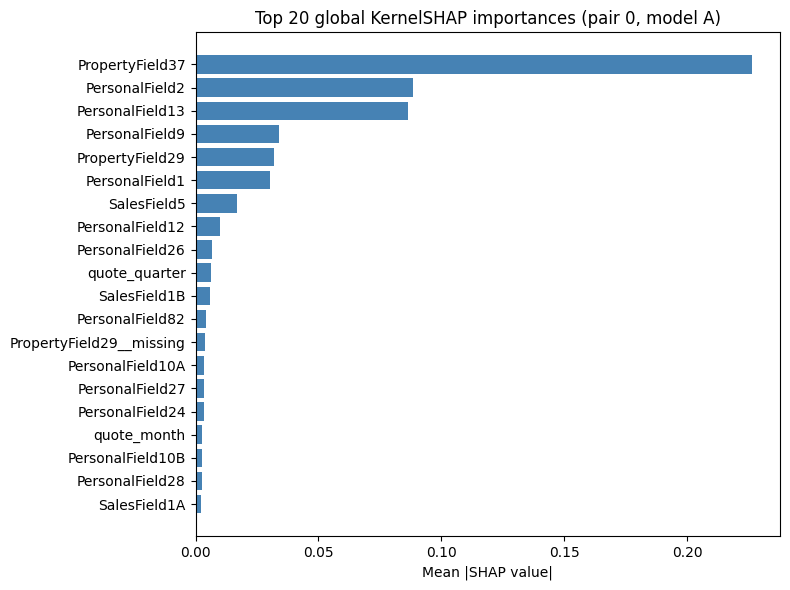

In [8]:
import matplotlib.pyplot as plt

shap_A_0 = np.load(SHAP_DIR / 'pair_00' / 'shap_A.npy')

phi_bar_A = shap_A_0.mean(axis=0)
global_imp = np.abs(phi_bar_A).mean(axis=0)
top_k = 20
top_idx = np.argsort(global_imp)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    [feature_names[i] for i in top_idx[::-1]],
    global_imp[top_idx[::-1]],
    color='steelblue'
)
ax.set_title(f'Top {top_k} global KernelSHAP importances (pair 0, model A)')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(SHAP_DIR / 'global_importance_pair00_A.png', dpi=120)
plt.show()
